<h1>PARTE: + Extra</h1>

In [1]:
import pandas as pd
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

<h2> 1-Tratamiento base</h2>


In [2]:
df=pd.read_csv("C:\\Users\\fatan\\Downloads\\data_regression_health.csv")
df[:10]


,Age,BMI,Exercise_Frequency,Diet_Quality,Sleep_Hours,Smoking_Status,Alcohol_Consumption,Health_Score
0,45.960570,31.996777,5,55.403270,7.300359,0,2.834707,70.542122
1,38.340828,29.623168,6,41.838357,7.012419,1,7.199517,57.244637
2,47.772262,25.298152,5,76.904948,6.028641,1,4.097944,96.333722
3,58.276358,21.765316,2,49.756767,5.802714,1,3.649377,61.321783
4,37.190160,28.491117,2,44.218737,7.912548,0,2.839795,67.175894
5,37.190357,26.967427,2,89.124837,7.786489,1,1.593758,100.000000
6,58.950554,29.475966,5,81.522693,7.085705,0,3.622786,91.385675
7,49.209217,28.175859,3,65.002425,8.386293,0,0.235395,94.853895
8,34.366307,30.247764,4,67.989301,4.058009,1,0.327432,78.356157
9,46.510721,22.323824,4,33.889837,6.153408,0,5.024877,64.380280


<h5> Variables</h5>

In [210]:
#Conteos
for col in df.columns:
    print(f'\n📊 Variable: {col}')
    display(pd.concat(
        [df[col].value_counts(), df[col].value_counts(1)],
        axis=1,
        keys=['Conteo', 'Proporción']
    ))


📊 Variable: Age


,Conteo,Proporción
45.960570,1,0.001
15.119317,1,0.001
42.377017,1,0.001
38.267675,1,0.001
33.116056,1,0.001
...,...,...
44.955177,1,0.001
33.235305,1,0.001
30.133355,1,0.001
42.924247,1,0.001



📊 Variable: BMI


,Conteo,Proporción
31.996777,1,0.001
23.165878,1,0.001
19.967287,1,0.001
30.699393,1,0.001
31.585575,1,0.001
...,...,...
23.059116,1,0.001
25.852081,1,0.001
25.802870,1,0.001
25.015230,1,0.001



📊 Variable: Exercise_Frequency


...

,Conteo,Proporción
0,501,0.501
1,499,0.499



📊 Variable: Alcohol_Consumption


,Conteo,Proporción
2.834707,1,0.001
3.978108,1,0.001
3.775197,1,0.001
1.346271,1,0.001
6.608569,1,0.001
...,...,...
3.011483,1,0.001
4.605562,1,0.001
4.291558,1,0.001
3.507458,1,0.001



📊 Variable: Health_Score


,Conteo,Proporción
100.000000,242,0.242
70.542122,1,0.001
68.625766,1,0.001
83.950901,1,0.001
85.939618,1,0.001
...,...,...
71.200686,1,0.001
75.874576,1,0.001
91.167406,1,0.001
48.158023,1,0.001


In [211]:
df.dtypes 

Age                    float64
BMI                    float64
Exercise_Frequency       int64
Diet_Quality           float64
Sleep_Hours            float64
Smoking_Status           int64
Alcohol_Consumption    float64
Health_Score           float64
dtype: object

In [3]:
#Types> Change

df['Age'] = df['Age'].astype(int)


var2 = ['Smoking_Status', 'Exercise_Frequency']
for i in var2:
    df[i] = df[i].astype('str')


In [4]:
df['Sleep_Hours'] = pd.to_numeric(df['Sleep_Hours'])
df['Sleep_Quality'] = np.where(df['Sleep_Hours'].between(7, 9), 'Adecuado',
                            np.where(df['Sleep_Hours'].isin([6, 10]), 'Marginal',
                            'Inadecuado'))

In [5]:
df

,Age,BMI,Exercise_Frequency,Diet_Quality,Sleep_Hours,Smoking_Status,Alcohol_Consumption,Health_Score,Sleep_Quality
0,45,31.996777,5,55.403270,7.300359,0,2.834707,70.542122,Adecuado
1,38,29.623168,6,41.838357,7.012419,1,7.199517,57.244637,Adecuado
2,47,25.298152,5,76.904948,6.028641,1,4.097944,96.333722,Inadecuado
3,58,21.765316,2,49.756767,5.802714,1,3.649377,61.321783,Inadecuado
4,37,28.491117,2,44.218737,7.912548,0,2.839795,67.175894,Adecuado
...,...,...,...,...,...,...,...,...,...
995,36,30.350751,1,60.674477,8.470913,0,3.823116,67.993747,Adecuado
996,61,24.867394,3,66.527725,5.355398,1,5.597395,72.377621,Inadecuado
997,47,20.590627,4,69.819819,8.641864,0,8.195167,100.000000,Adecuado
998,33,24.184665,6,70.724204,7.941557,0,3.676134,100.000000,Adecuado


In [6]:
#Nos quedamos con dosis positivas 
df= df[df['Alcohol_Consumption'] >= 0]

In [7]:
df.dtypes 

Age                      int32
BMI                    float64
Exercise_Frequency      object
Diet_Quality           float64
Sleep_Hours            float64
Smoking_Status          object
Alcohol_Consumption    float64
Health_Score           float64
Sleep_Quality           object
dtype: object

In [8]:
col_num = [x for x in df.columns if df.dtypes[x]!='O']
col_num

col_cat= [x for x in df.columns if df.dtypes[x]=='O']
col_cat

['Exercise_Frequency', 'Smoking_Status', 'Sleep_Quality']

<h2> 2-Componentes</h2>

In [9]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

<h5>Normalizamos</h5>

In [10]:
scaler= StandardScaler()
scaler.fit(df[col_num])

var_std = scaler.transform(df[col_num])
var_std[:5]

array([[ 0.43223715,  1.33070584, -0.9632803 ,  0.22122074, -0.29634487,
        -1.05742054],
       [-0.162283  ,  0.85691901, -1.86397835,  0.03155752,  2.08633071,
        -2.02196007],
       [ 0.60210005, -0.00638075,  0.46441187, -0.61644655,  0.39323465,
         0.81338571],
       [ 1.536346  , -0.71155638, -1.33820299, -0.76526183,  0.14836971,
        -1.72622231],
       [-0.24721445,  0.63095454, -1.70592326,  0.6244629 , -0.29356738,
        -1.30159149]])

In [11]:
for num, i in enumerate(col_num):
    df[i] = var_std[:, num]

df[:5]

C:\Users\fatan\AppData\Local\Temp\ipykernel_9440\1129596202.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[i] = var_std[:, num]


,Age,BMI,Exercise_Frequency,Diet_Quality,Sleep_Hours,Smoking_Status,Alcohol_Consumption,Health_Score,Sleep_Quality
0,0.432237,1.330706,5,-0.963280,0.221221,0,-0.296345,-1.057421,Adecuado
1,-0.162283,0.856919,6,-1.863978,0.031558,1,2.086331,-2.021960,Adecuado
2,0.602100,-0.006381,5,0.464412,-0.616447,1,0.393235,0.813386,Inadecuado
3,1.536346,-0.711556,2,-1.338203,-0.765262,1,0.148370,-1.726222,Inadecuado
4,-0.247214,0.630955,2,-1.705923,0.624463,0,-0.293567,-1.301591,Adecuado


<h5>Dummies</h5>

In [13]:
cols = list(set(col_num + col_cat) - set(['Sleep_Hours']))
df_dum = pd.get_dummies(df[cols], drop_first=True)
df_dum[:5]

,Health_Score,Diet_Quality,BMI,Alcohol_Consumption,Age,Smoking_Status_1,Exercise_Frequency_1,Exercise_Frequency_2,Exercise_Frequency_3,Exercise_Frequency_4,Exercise_Frequency_5,Exercise_Frequency_6,Sleep_Quality_Inadecuado
0,-1.057421,-0.963280,1.330706,-0.296345,0.432237,0,0,0,0,0,1,0,0
1,-2.021960,-1.863978,0.856919,2.086331,-0.162283,1,0,0,0,0,0,1,0
2,0.813386,0.464412,-0.006381,0.393235,0.602100,1,0,0,0,0,1,0,1
3,-1.726222,-1.338203,-0.711556,0.148370,1.536346,1,0,1,0,0,0,0,1
4,-1.301591,-1.705923,0.630955,-0.293567,-0.247214,0,0,1,0,0,0,0,0


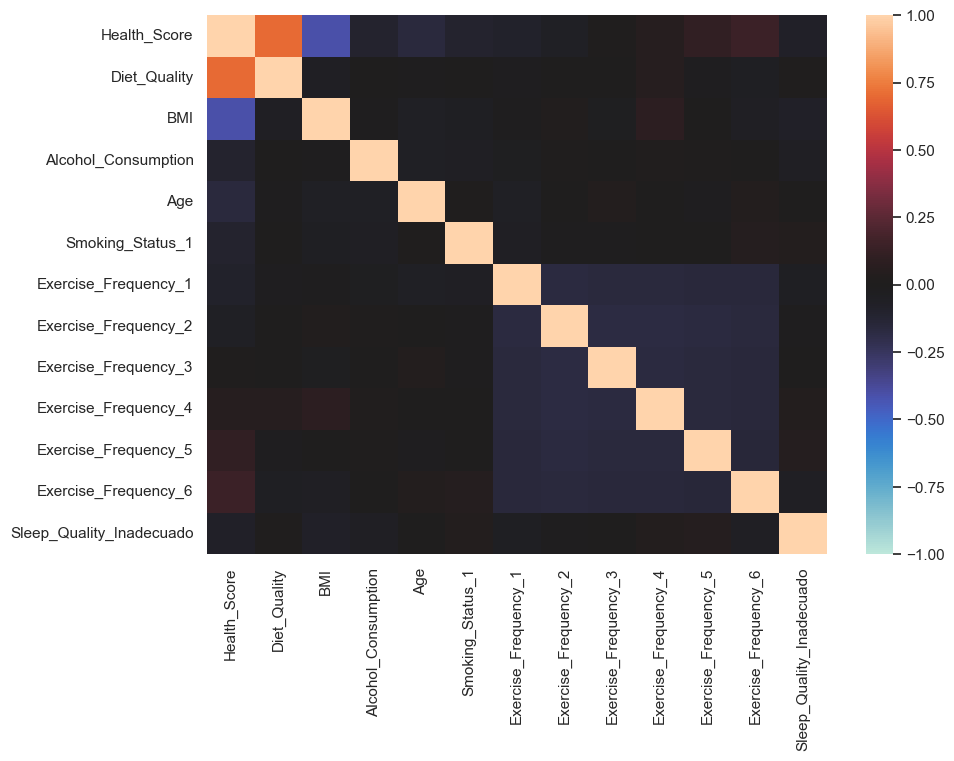

In [14]:
plt.figure(figsize=(10, 7))
sns.heatmap(df_dum.corr(method='spearman'), vmin=-1, vmax=1, center=0)
plt.show()

<h5>Objeto PCA</h5>

In [15]:
CP = PCA(n_components=None, whiten=True, random_state=40)

In [16]:
## Entrenamiento
CP.fit( df_dum )

## Componentes principales con una nueva base
CP.transform( df_dum )

## Varianza explicada
CP.explained_variance_

## Varianza porcentual explicada
CP.explained_variance_ratio_

array([0.29842095, 0.17268021, 0.15729447, 0.14898277, 0.04796269,
       0.03845626, 0.02982479, 0.02373401, 0.02304677, 0.0221514 ,
       0.02036263, 0.01391656, 0.0031665 ])

In [17]:
np.arange(len(df_dum.columns)) + 1

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13])

<h5>% Varianza explicada</h5>

Varianza expicada: 
[0.3  0.17 0.16 0.15 0.05 0.04 0.03 0.02 0.02 0.02 0.02 0.01 0.  ]


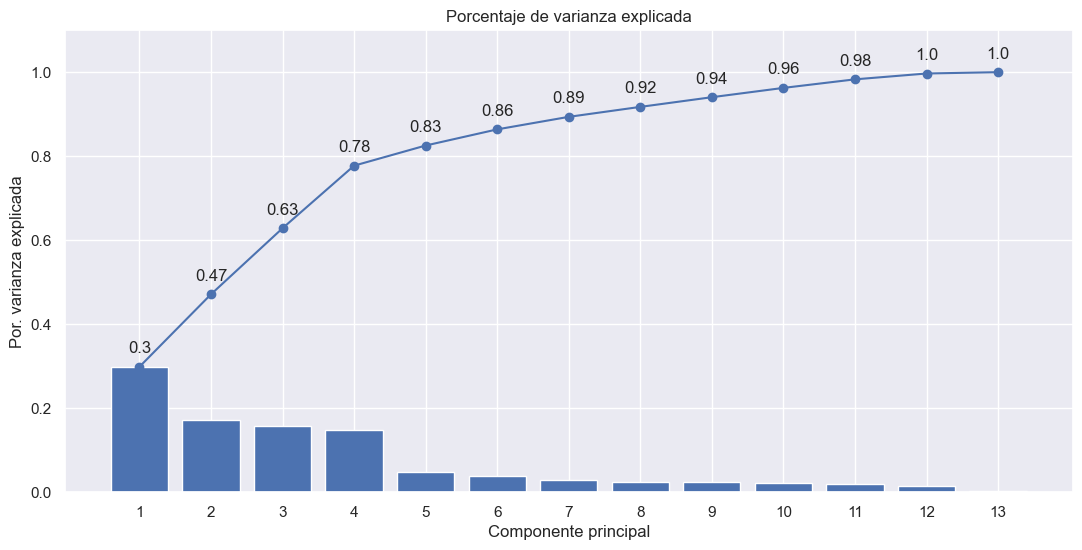

In [18]:
print('Varianza expicada: ')
print(CP.explained_variance_ratio_.round(2))

prop_varianza_acum= np.cumsum(CP.explained_variance_ratio_)
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(13, 6))

ax.plot(
    np.arange(len(df_dum.columns))[:20] + 1,
    prop_varianza_acum[:20],
    marker = 'o'    
)

ax.bar(
    x = np.arange(len(df_dum.columns))[:20] + 1,
    height = CP.explained_variance_ratio_[:20]
)

for x, y in zip(np.arange(len(df_dum.columns))[:20] + 1, prop_varianza_acum[:20]):
    ax.annotate(
        round(y, 2),
        (x, y),
        textcoords = "offset points",
        xytext = (0, 10),
        ha = 'center'        
    )
    

ax.set_xticks(np.arange(CP.n_components_)[:20] + 1)
ax.set_ylim(0, 1.1)
ax.set_title('Porcentaje de varianza explicada')
ax.set_xlabel('Componente principal')
ax.set_ylabel('Por. varianza explicada');

<h5>Peso de variables en los componentes</h5>

In [19]:
pesos = CP.components_.T
pesos = pd.DataFrame(pesos, columns = ['CP'+str(i) for i in range(1, len(CP.explained_variance_)+1)], 
                     index = df_dum.columns).round(4)
pesos

,CP1,CP2,CP3,CP4,CP5,CP6,CP7,CP8,CP9,CP10,CP11,CP12,CP13
Health_Score,-0.7003,0.0069,-0.0410,0.0171,-0.3800,0.0406,-0.3956,0.0355,0.0423,-0.0019,0.0532,-0.4280,0.1264
Diet_Quality,-0.5881,0.0599,-0.2348,-0.5054,0.3471,-0.0347,0.3258,-0.0176,-0.0230,0.0271,-0.0293,0.3185,-0.0908
BMI,0.3728,0.2646,-0.6702,-0.4746,-0.1660,0.0071,-0.2090,0.0022,0.0436,0.0290,0.0511,-0.1918,0.0560
Alcohol_Consumption,0.0659,0.6384,0.6361,-0.4132,-0.0247,0.0063,-0.0747,0.0028,0.0051,0.0146,0.0182,-0.0746,0.0199
Age,0.1394,-0.7181,0.2967,-0.5871,-0.1111,0.0113,-0.0852,0.0118,-0.0102,0.0203,0.0033,-0.1057,0.0240
Smoking_Status_1,0.0152,-0.0298,-0.0033,0.0203,0.6114,0.6995,-0.2907,0.0061,0.0138,0.0252,-0.0011,-0.2217,0.0296
Exercise_Frequency_1,0.0101,0.0087,-0.0085,0.0263,0.0298,-0.0231,0.4143,-0.1933,-0.3854,0.4106,0.1849,-0.5620,-0.3484
Exercise_Frequency_2,0.0139,0.0055,-0.0044,-0.0068,0.0278,-0.0094,0.2070,0.7860,0.2942,-0.2153,-0.0391,-0.2584,-0.3700
Exercise_Frequency_3,-0.0055,-0.0124,0.0137,-0.0087,0.0068,-0.0113,0.0728,-0.5742,0.6376,-0.2791,-0.0577,-0.1712,-0.3837
Exercise_Frequency_4,-0.0077,0.0167,-0.0239,-0.0332,-0.0050,-0.0334,-0.2195,-0.0912,-0.5886,-0.6017,-0.2555,0.0026,-0.4081


In [20]:
dc_comp= pd.DataFrame(CP.transform(df_dum), columns = ['Salud_Nutricion', 'Edad_Alcohol','Estilo_Peso']+['CP'+str(i) for i in range(4, len(CP.explained_variance_)+1)])
dc_comp

,Salud_Nutricion,Edad_Alcohol,Estilo_Peso,CP4,CP5,CP6,CP7,CP8,CP9,CP10,CP11,CP12,CP13
0,1.337549,-0.164594,-0.694132,-0.319131,-1.597357,0.066268,-0.340302,0.035856,0.167464,1.561132,-1.697624,1.199209,-0.744763
1,2.154816,1.488417,1.246631,-0.273463,-0.315085,1.777933,-0.754031,-0.017695,-0.054642,0.266821,1.941471,1.355284,-0.916839
2,-0.538669,-0.170081,0.300223,-0.723696,0.476771,0.108236,-2.015762,0.222434,0.284371,1.749500,-1.266106,-0.753972,0.052886
3,1.454691,-1.270224,1.428775,0.038860,1.295732,0.077675,0.412342,2.008866,0.579673,-0.519877,-0.135143,-0.350659,-0.758537
4,1.541436,0.084340,-0.241125,0.802874,-1.386662,0.116872,1.054466,1.938349,0.702615,-0.720518,-0.312518,-0.076405,-0.411766
...,...,...,...,...,...,...,...,...,...,...,...,...,...
925,1.155220,0.635418,-0.438952,-0.097364,-0.849726,0.026548,2.051909,-0.652445,-1.100482,1.091117,0.315938,-0.359434,-0.701054
926,0.794315,-0.581064,1.490232,-1.451206,1.118721,0.089805,-0.328691,-1.490280,1.587727,-0.510438,-0.013444,-0.779980,-0.411719
927,-0.635751,1.019216,2.441052,-1.070830,-1.848825,0.179085,-0.747059,-0.164893,-1.632273,-1.611649,-0.774107,-0.830801,0.293419
928,-0.712578,0.480962,0.036951,0.373432,-1.870139,0.418228,-0.532627,0.131931,-0.000133,0.139596,1.991278,1.021237,-0.353976


<h5>CP1</h5>

In [229]:
menores = dc_comp.Salud_Nutricion.sort_values().index[:2]
mayores = dc_comp.Salud_Nutricion.sort_values(ascending=False).index[:2]

display( df[df.index.isin(menores)] )
df[df.index.isin(mayores)]

,Age,BMI,Exercise_Frequency,Diet_Quality,Sleep_Hours,Smoking_Status,Alcohol_Consumption,Health_Score,Sleep_Quality
382,-2.200638,2.087166,1,0.438069,0.815300,1,-0.652928,-0.103067,Adecuado
804,-0.502009,-1.865482,1,0.268441,-0.544693,0,-0.766906,1.079321,Inadecuado


,Age,BMI,Exercise_Frequency,Diet_Quality,Sleep_Hours,Smoking_Status,Alcohol_Consumption,Health_Score,Sleep_Quality
101,-0.502009,-2.956445,4,0.227471,-0.301175,0,0.919969,1.079321,Inadecuado
892,1.026757,-0.501420,2,-1.179493,0.821666,1,-0.006088,-1.653897,Adecuado


<h5>CP2</h5>

In [230]:
menores = dc_comp.Edad_Alcohol.sort_values().index[:2]
mayores = dc_comp.Edad_Alcohol.sort_values(ascending=False).index[:2]

display( df[df.index.isin(menores)] )
df[df.index.isin(mayores)]

,Age,BMI,Exercise_Frequency,Diet_Quality,Sleep_Hours,Smoking_Status,Alcohol_Consumption,Health_Score,Sleep_Quality
195,0.347306,0.373714,0,1.062486,-0.084548,1,-0.870285,0.388353,Inadecuado
546,0.517169,-1.062313,0,0.699864,1.190600,0,0.521140,1.068027,Adecuado


,Age,BMI,Exercise_Frequency,Diet_Quality,Sleep_Hours,Smoking_Status,Alcohol_Consumption,Health_Score,Sleep_Quality
18,-0.926666,-0.385610,6,-0.588072,-0.236021,1,-0.714836,0.424608,Inadecuado
67,1.026757,1.092647,3,0.111678,-0.967832,0,0.442940,-0.660153,Inadecuado


<h5>CP3</h5>

In [231]:
menores = dc_comp.Estilo_Peso.sort_values().index[:2]
mayores = dc_comp.Estilo_Peso.sort_values(ascending=False).index[:2]

display( df[df.index.isin(menores)] )
df[df.index.isin(mayores)]

,Age,BMI,Exercise_Frequency,Diet_Quality,Sleep_Hours,Smoking_Status,Alcohol_Consumption,Health_Score,Sleep_Quality
360,0.517169,-0.081173,0,1.545438,1.557834,0,-0.093051,1.079321,Inadecuado
891,0.517169,-0.059484,1,0.191669,0.020690,1,0.385148,-0.419606,Inadecuado


,Age,BMI,Exercise_Frequency,Diet_Quality,Sleep_Hours,Smoking_Status,Alcohol_Consumption,Health_Score,Sleep_Quality
54,1.026757,-0.615115,0,0.116168,0.325835,1,-1.312475,0.270303,Adecuado
460,1.961003,-0.204077,3,-0.824708,-0.810638,1,2.441846,-1.393611,Inadecuado


## PCA desde 0

<h5>Matriz de covarianza</h5>

In [41]:
cov_matrix = np.cov(df_dum, rowvar=False)

<h5>Eigenvalores y eigenvectores</h5>

In [42]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

<h5>Componentes ordenados</h5>

In [43]:
idx = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

<h5>Obtencion  de los PCA</h5>

In [44]:
Z = df_dum @ eigenvectors
Z

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,-1.832312,-0.206574,0.681353,0.279536,0.254818,0.027871,0.523353,-0.036722,0.104372,0.596637,0.524980,0.057512,-0.402881
1,-2.945448,1.506067,-1.237751,0.235587,-0.445349,-0.809026,0.701498,-0.016152,0.020303,0.116341,-0.769752,0.103418,-0.427024
2,0.723139,-0.212260,-0.301905,0.668873,-0.877731,0.007351,1.244780,-0.108388,0.148622,0.666537,0.371452,-0.516972,-0.290971
3,-1.991862,-1.352089,-1.417863,-0.064980,-1.324913,0.022293,0.199276,-0.794574,0.260396,-0.175588,-0.030926,-0.398347,-0.404814
4,-2.110010,0.051340,0.233402,-0.800237,0.139771,0.003129,-0.077213,-0.767488,0.306930,-0.250043,0.032181,-0.317681,-0.356162
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,-1.583976,0.622297,0.429021,0.066117,-0.153416,0.047291,-0.506695,0.227661,-0.375555,0.422223,-0.191413,-0.400928,-0.396749
996,-1.092415,-0.638068,-1.478634,1.369000,-1.228259,0.016362,0.518353,0.549482,0.641952,-0.172086,-0.074225,-0.524622,-0.356155
997,0.855366,1.019940,-2.418843,1.002941,0.392128,-0.027290,0.698496,0.040388,-0.576842,-0.580726,0.196407,-0.539570,-0.257224
998,0.960006,0.462269,-0.041571,-0.386959,0.403767,-0.144216,0.606165,-0.073625,0.040935,0.069130,-0.787472,0.005165,-0.348054


<h5>Varianza Explicada</h5>

In [45]:
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance_ratio)

Varianza explicada:
[0.3  0.17 0.16 0.15 0.05 0.04 0.03 0.02 0.02 0.02 0.02 0.01 0.  ]


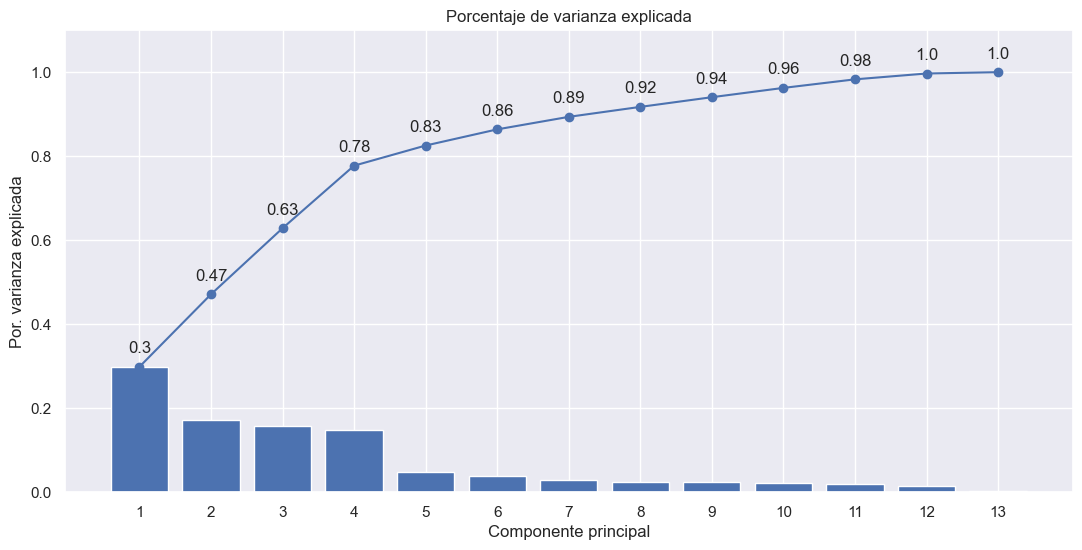

In [46]:
print('Varianza explicada:')
print(np.round(explained_variance_ratio, 2))

prop_varianza_acum = np.cumsum(explained_variance_ratio)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(13, 6))

ax.plot(
    np.arange(len(df_dum.columns))[:20] + 1,
    prop_varianza_acum[:20],
    marker='o'
)

ax.bar(
    x = np.arange(len(df_dum.columns))[:20] + 1,
    height = explained_variance_ratio[:20]
)

for x, y in zip(np.arange(len(df_dum.columns))[:20] + 1, prop_varianza_acum[:20]):
    ax.annotate(
        round(y, 2),
        (x, y),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center'
    )

ax.set_xticks(np.arange(len(explained_variance_ratio))[:20] + 1)
ax.set_ylim(0, 1.1)
ax.set_title('Porcentaje de varianza explicada')
ax.set_xlabel('Componente principal')
ax.set_ylabel('Por. varianza explicada')

plt.show()

In [48]:
loadings = pd.DataFrame(
    eigenvectors,
    columns=[f'PC{i+1}' for i in range(eigenvectors.shape[1])],
    index=df_dum.columns
)

print(loadings.round(3))

                            PC1    PC2    PC3    PC4    PC5    PC6    PC7  \
Health_Score              0.700  0.007  0.041 -0.017  0.380 -0.041  0.396   
Diet_Quality              0.588  0.060  0.235  0.505 -0.347  0.035 -0.326   
BMI                      -0.373  0.265  0.670  0.475  0.166 -0.007  0.209   
Alcohol_Consumption      -0.066  0.638 -0.636  0.413  0.025 -0.006  0.075   
Age                      -0.139 -0.718 -0.297  0.587  0.111 -0.011  0.085   
Smoking_Status_1         -0.015 -0.030  0.003 -0.020 -0.611 -0.699  0.291   
Exercise_Frequency_1     -0.010  0.009  0.008 -0.026 -0.030  0.023 -0.414   
Exercise_Frequency_2     -0.014  0.006  0.004  0.007 -0.028  0.009 -0.207   
Exercise_Frequency_3      0.005 -0.012 -0.014  0.009 -0.007  0.011 -0.073   
Exercise_Frequency_4      0.008  0.017  0.024  0.033  0.005  0.033  0.220   
Exercise_Frequency_5      0.011  0.006 -0.001 -0.015  0.061  0.031  0.335   
Exercise_Frequency_6      0.016 -0.013 -0.016 -0.010  0.111 -0.110  0.282   